# **07. Model Evaluation**

### **Introduction**

Multiple baseline machine learning models were trained and evaluated using the ROC-AUC score. The best-performing model was selected for hyperparameter tuning using GridSearchCV. The optimized model was then retrained with the best parameters and evaluated using standard classification metrics, including accuracy, precision, recall, F1-score, and ROC-AUC.


In [17]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sidetable
import sklearn
import feature_engine
import scipy
from scipy import stats
import time
from pathlib import Path
import pickle
import joblib
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score,
    RocCurveDisplay,
    ConfusionMatrixDisplay
)



In [2]:
# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
from IPython.display import display, Markdown

def display_md(string):
    display(Markdown(string))
    

## **1. Loading Preprocessed Model Data**

In [24]:
# define path for best model and base_model
parent_path = Path.cwd().parent
best_model_path = parent_path.joinpath('models', 'best_model.pkl')

base_model_path = parent_path.joinpath('models', 'logistic_regression_model.pkl')


In [11]:
display_md("**Loading Best & Base Model Data....**")
with open(best_model_path, 'rb') as file:
    best_model_data = joblib.load(file)
    
with open(base_model_path, 'rb') as file:
    base_model_data = joblib.load(file)
    

**Loading Best & Base Model Data....**

In [5]:
best_model_data.keys()

dict_keys(['model', 'best_pipeline', 'selected_features', 'full_preprocessed_train', 'y_train', 'full_preprocessed_test', 'y_test'])

In [6]:
# Load the best model and its components
best_model = best_model_data['model']
best_model_pipeline = best_model_data['best_pipeline']
selected_features = best_model_data['selected_features']
X_train = best_model_data['full_preprocessed_train']
X_test = best_model_data['full_preprocessed_test']
y_train = best_model_data['y_train']
y_test = best_model_data['y_test']
X_train_new = X_train[selected_features]
X_test_new = X_test[selected_features]


## **2. Hyperparameter Tuning for XGBoost Classifier**

In [7]:
# store tuning results in list
tuning_results = []

# Initialize the XGBClassifier
xgb_model_pipeline = best_model_pipeline

# Define parameters grid
parameters_dict = {
    'classifier__min_child_weight': [1, 5, 10],
    'classifier__gamma': [0.5, 1, 1.5, 2, 5],
    'classifier__subsample': [0.6, 0.8, 1.0],       # fraction of samples to be used for fitting the individual base learners
    'classifier__colsample_bytree': [0.6, 0.8, 1.0], # fraction of features to be used for fitting the individual base learners
    'classifier__max_depth': [3, 4, 5]
}

# Set up stratified k-fold cross-validation
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb_model_pipeline,
    param_grid=parameters_dict,
    scoring='roc_auc',
    n_jobs=-1,
    cv=kfold,
    verbose=1
)

# Measuring training time
start_time = time.time()
# Fit the model
grid_search.fit(X_train_new, y_train)
end_time = time.time()
training_time = end_time - start_time

# Get the best parameters , best score and best pipeline
best_model_pipeline = grid_search.best_estimator_
best_params = grid_search.best_params_
best_score = grid_search.best_score_

display_md(f"**Best Parameters: {best_params}**")
display_md(f"**Best ROC AUC Score: {best_score}**")
display_md(f"**Training Time: {training_time} seconds**")

tuning_results.append({
    'model': best_model,
    'best_params': best_params,
    'best_roc_auc_score': best_score,
    'training_time': training_time
})

# Save the tuning results as dataframe
tuning_results_df = pd.DataFrame(tuning_results)


Fitting 5 folds for each of 405 candidates, totalling 2025 fits


c:\Users\Admin\anaconda3\envs\test_titanic\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:24:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


**Best Parameters: {'classifier__colsample_bytree': 0.8, 'classifier__gamma': 2, 'classifier__max_depth': 4, 'classifier__min_child_weight': 10, 'classifier__subsample': 1.0}**

**Best ROC AUC Score: 0.9295482126066303**

**Training Time: 559.9456884860992 seconds**

## **3. Selecting Final Model & Saving**

In [8]:
display(tuning_results_df)

display_md(f"**=== BEST MODEL ===**")
print(f"Best Model : {tuning_results_df['model'].iloc[0]}")  # Display the best model  
print(f"Best Parameters: {best_params}")
print(f"Best ROC AUC Score: {best_score}")

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

try:
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=50)
    cv_results = cross_validate(xgb_model_pipeline, X_train_new, y_train, cv=kf, scoring=scoring, n_jobs=-1)
    cv_accuracy_prev = cv_results['test_accuracy'].mean()
    cv_precision_prev = cv_results['test_precision'].mean()
    cv_recall_prev = cv_results['test_recall'].mean()
    cv_f1_prev = cv_results['test_f1'].mean()
    cv_roc_auc_prev = cv_results['test_roc_auc'].mean()

    improvement = best_score - cv_roc_auc_prev
    percent_improvement = (improvement / cv_roc_auc_prev) * 100 if cv_roc_auc_prev != 0 else 0

    print(f"Basline ROC AUC Score (from cross-validation): {cv_roc_auc_prev:.4f}")
    print(f"Tuned Model ROC AUC Score: {best_score:.4f}")
    print(f"Improvement : {improvement:.4f} ({percent_improvement:.2f}%)")

except Exception as e:
    print(f"\nNo best model found. Error: {e}")


,model,best_params,best_roc_auc_score,training_time
0,xgboost,"{'classifier__colsample_bytree': 0.8, 'classif...",0.929548,559.945688


**=== BEST MODEL ===**

Best Model : xgboost
Best Parameters: {'classifier__colsample_bytree': 0.8, 'classifier__gamma': 2, 'classifier__max_depth': 4, 'classifier__min_child_weight': 10, 'classifier__subsample': 1.0}
Best ROC AUC Score: 0.9295482126066303
Basline ROC AUC Score (from cross-validation): 0.9211
Tuned Model ROC AUC Score: 0.9295
Improvement : 0.0085 (0.92%)


In [9]:
best_model_pipeline = grid_search.best_estimator_

# Save the final best model in .pkl file for furthur use
model_dir = parent_path.joinpath("models")
model_dir.mkdir(parents=True, exist_ok=True)

# Define file path inside ,odel directory
final_model_file = model_dir.joinpath("final_tuned_model.pkl")

# Save the final tuned model
with open(final_model_file, 'wb') as f:
    joblib.dump(best_model_pipeline, f)

print("Final tuned model saved successfully!!!!")


Final tuned model saved successfully!!!!


In [25]:
# Load back the fined-tuned model to verify
with open(final_model_file, 'rb') as file:
    final_tuned_pipeline = joblib.load(file)


## **4. Training With Hyper-Tuned XGBoost Model**

In [ ]:
print(tuning_results_df['best_params'].iloc[0])

xgb_params = {
    k.replace('classifier__', ''): v
    for k, v in tuning_results_df['best_params'].iloc[0].items()
    if k.startswith('classifier__')
}
print("\n", xgb_params)


{'classifier__colsample_bytree': 0.8, 'classifier__gamma': 2, 'classifier__max_depth': 4, 'classifier__min_child_weight': 10, 'classifier__subsample': 1.0}

 {'colsample_bytree': 0.8, 'gamma': 2, 'max_depth': 4, 'min_child_weight': 10, 'subsample': 1.0}


In [56]:
# Fit XGBoost model with best parameters
best_xgb = XGBClassifier(
    **xgb_params,
    use_label_encoder=False,  # Disable label encoding for binary classification
    scale_pos_weight=7.5,  # Adjust this based on class imbalance if needed
    eval_metric='logloss'  # Use log loss as the evaluation metric for binary classification
)
best_xgb.fit(X_train_new, y_train)

# Evaluate model
y_train_pred = best_xgb.predict(X_train_new)
y_train_proba = best_xgb.predict_proba(X_train_new)[:, 1]
y_test_pred = best_xgb.predict(X_test_new)
y_test_proba = best_xgb.predict_proba(X_test_new)[:, 1]

# Comprehensive metrics function
def calculate_metrics(y_true, y_pred, y_prob, model_name):
    """
    Compute all relevant metrics for imbalanced classification problem
    """
    metrics = {}
    metrics['model'] = model_name
    metrics['accuracy'] = accuracy_score(y_true, y_pred)
    metrics['precision'] = precision_score(y_true, y_pred)
    metrics['recall'] = recall_score(y_true, y_pred)
    metrics['f1_score'] = f1_score(y_true, y_pred)
    metrics['roc_auc'] = roc_auc_score(y_true, y_prob)
    
    # balance accuracy
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp/ (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn/ (tn + fp) if (tn + fp) > 0 else 0
    metrics['balanced_accuracy'] = (sensitivity + specificity) / 2

    return metrics

training_metrics = calculate_metrics(y_train, y_train_pred, y_train_proba, "Trained XGBoost Model")
display_md("**Training Metrics:**")
for key, value in training_metrics.items():
    if key != 'model':
        print(f"{key.replace('_', ' ').capitalize()}: {value:.4f}")

cm_training = confusion_matrix(y_train, y_train_pred)
display_md("**Confusion Matrix (Training):**")
print(cm_training)

test_metrics = calculate_metrics(y_test, y_test_pred, y_test_proba, "Testing XGBoost Model")
display_md("**Testing Metrics:**")
for key, value in test_metrics.items():
    if key != 'model':
        print(f"{key.replace('_', ' ').capitalize()}: {value:.4f}")

cm_testing = confusion_matrix(y_test, y_test_pred)
display_md("**Confusion Matrix (Testing):**")
print(cm_testing)

display_md("**Classification Report:**")
print(classification_report(y_test, y_test_pred)) 



c:\Users\Admin\anaconda3\envs\test_titanic\Lib\site-packages\xgboost\training.py:200: UserWarning: [02:21:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


**Training Metrics:**

Accuracy: 0.8600
Precision: 0.4521
Recall: 0.9275
F1 score: 0.6079
Roc auc: 0.9492
Balanced accuracy: 0.8893


**Confusion Matrix (Training):**

[[22761  3984]
 [  257  3287]]


...

Accuracy: 0.8484
Precision: 0.4277
Recall: 0.8762
F1 score: 0.5748
Roc auc: 0.9293
Balanced accuracy: 0.8605


**Confusion Matrix (Testing):**

[[11128  2046]
 [  216  1529]]


**Classification Report:**

              precision    recall  f1-score   support

           0       0.98      0.84      0.91     13174
           1       0.43      0.88      0.57      1745

    accuracy                           0.85     14919
   macro avg       0.70      0.86      0.74     14919
weighted avg       0.92      0.85      0.87     14919



## **5. Customer Classification**

In [57]:
# prob for class 1
p = best_xgb.predict_proba(X_test_new)[:, 1]

# create a DataFrame with a probabilities
pred_df = X_test_new.copy()
pred_df['predicted_proba'] = p

# sort the DataFrame by predicted probabilities in descending order
pred_df = pred_df.sort_values(by='predicted_proba', ascending=False)

# Define the thresholds for categorizing groups
high_prob_threshold = 0.8
medium_prob_threshold = 0.5

# Categorize the predicted probabilities into groups
pred_df['group'] = pd.cut(
    pred_df['predicted_proba'],
    bins=[0.3, medium_prob_threshold, high_prob_threshold, 1],
    labels=['Low', 'Medium', 'High']
)

# Analyze the groups
high_prob_group = pred_df[pred_df['group'] == 'High']
medium_prob_group = pred_df[pred_df['group'] == 'Medium']
low_prob_group = pred_df[pred_df['group'] == 'Low']

# Print the number of customers in each group
print(f"High Probability Group: {len(high_prob_group)} customers")
print(f"Medium Probability Group: {len(medium_prob_group)} customers")
print(f"Low Probability Group: {len(low_prob_group)} customers")


High Probability Group: 1847 customers
Medium Probability Group: 1728 customers
Low Probability Group: 1078 customers


## **6. Model Evaluation Using Accuracy, Precision, F1-Score, ROC-AUC**

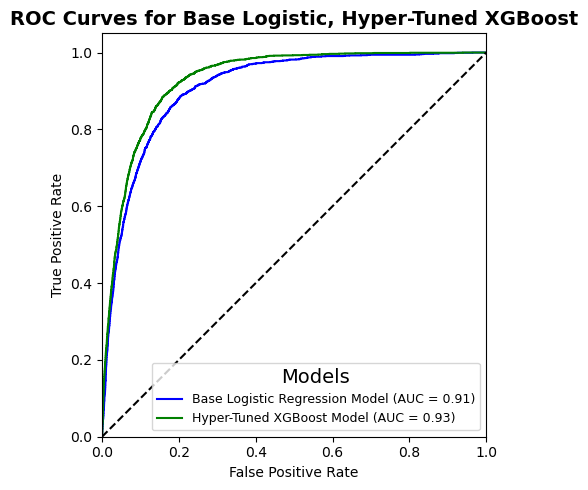

In [43]:

base_pipeline = base_model_data
final_pipeline = final_tuned_pipeline

# Visualization of ROC Curve for both base and tuned model
fig, ax = plt.subplots(figsize=(15, 5))

# base logistic regression model
RocCurveDisplay.from_estimator(base_pipeline, X_test_new[base_pipeline.feature_names_in_], y_test, ax=ax, name="Base Logistic Regression Model", color='blue')

# tuned XGBoost model
RocCurveDisplay.from_estimator(final_pipeline, X_test_new, y_test, ax=ax, name='Hyper-Tuned XGBoost Model', color='green')

# Plot diagonal line
ax.plot([0, 1], [0, 1], 'k--')

# Set limits and labels
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves for Base Logistic, Hyper-Tuned XGBoost', fontdict={'weight': 'bold', 'size': 14})


# legend and title
ax.legend(loc='lower right', title='Models', fontsize=9, title_fontsize=14)

plt.tight_layout()
plt.show()

